In [1]:
!pip install kagglehub -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.6 MB/s eta 0:00:00


In [2]:
import kagglehub

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset descargado en: /kaggle/input/intel-image-classification


In [4]:
tf.config.optimizer.set_jit(True)

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255, # (normalizar en DL = escalar en ML)
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    path + '/seg_train/seg_train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    path + '/seg_train/seg_train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [6]:
# @title
def build_classifier(input_shape=(64, 64, 3), num_classes=6):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),

        Dense(516, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation='softmax', dtype='float32')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [7]:
modelo_clf = build_classifier()
modelo_clf.summary()

run_id = datetime.now().strftime("%Y%m%d_%H%M")

# Automatizan el control de calidad
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f"modelo_clf_{run_id}_BEST.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1
    )
]

hist_clf = modelo_clf.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    verbose=1,
    callbacks=callbacks
)
print("Entrenamiento finalizado.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 516)            │     6,341,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 516)            │         2,064 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 516)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       132,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,510,746 (24.84 MB)

 Trainable params: 6,508,946 (24.83 MB)

 Non-trainable params: 1,800 (7.03 KB)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.3784 - loss: 1.7699
Epoch 1: val_loss improved from None to 1.33573, saving model to modelo_clf_20260911_0609_BEST.keras

Epoch 1: finished saving model to modelo_clf_20260911_0609_BEST.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 101s 545ms/step - accuracy: 0.4265 - loss: 1.6082 - val_accuracy: 0.4957 - val_loss: 1.3357 - learning_rate: 3.0000e-04
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4693 - loss: 1.4287
Epoch 2: val_loss did not improve from 1.33573
176/176 ━━━━━━━━━━━━━━━━━━━━ 29s 166ms/step - accuracy: 0.4763 - loss: 1.4006 - val_accuracy: 0.4690 - val_loss: 1.3494 - learning_rate: 3.0000e-04
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4972 - loss: 1.3337
Epoch 3: val_loss improved from 1.33573 to 1.31516, saving model to modelo_clf_20260911_0609_BEST.keras

Epoch 3: finished saving model to modelo_clf_20260911_0609_BEST.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 30s 168ms/step -

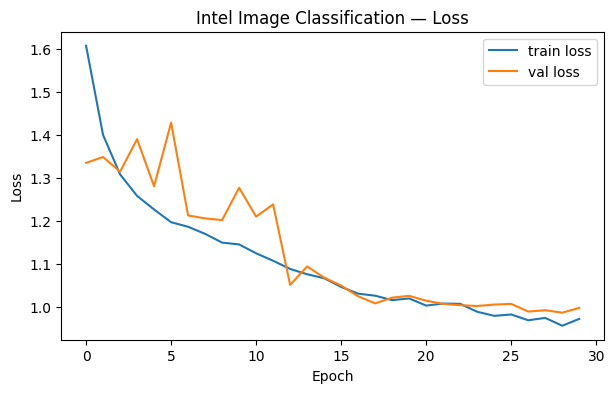

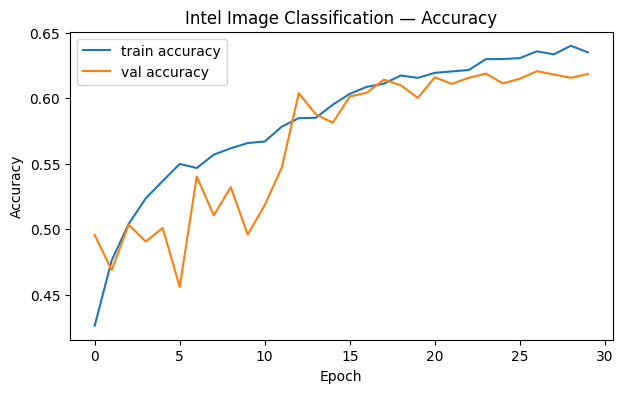

In [35]:
# @title
def plot_history(history, title="Curvas de aprendizaje"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="val loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in hist.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(hist["accuracy"], label="train accuracy")
        plt.plot(hist["val_accuracy"], label="val accuracy")
        plt.title(title + " — Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

plot_history(hist_clf, "Intel Image Classification")

In [33]:
test_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = test_datagen.flow_from_directory(
    path + '/seg_test/seg_test', # path + '/seg_train/seg_train' con subset='validation'
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

y_true = eval_generator.classes

y_prob = modelo_clf.predict(eval_generator)
y_pred = np.argmax(y_prob, axis=-1)

metricas_clf = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision (Weighted)", "Recall (Weighted)", "F1-score (Weighted)"],
    "Valor": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]
})
print(metricas_clf)

nombres_clases = list(eval_generator.class_indices.keys())
print("\nReporte detallado por clase:")
print(classification_report(y_true, y_pred, target_names=nombres_clases))

Found 3000 images belonging to 6 classes.
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step
                Métrica     Valor
0              Accuracy  0.626333
1  Precision (Weighted)  0.625279
2     Recall (Weighted)  0.626333
3   F1-score (Weighted)  0.622559

Reporte detallado por clase:
              precision    recall  f1-score   support

   buildings       0.52      0.46      0.49       437
      forest       0.81      0.76      0.79       474
     glacier       0.58      0.72      0.64       553
    mountain       0.63      0.67      0.65       525
         sea       0.55      0.42      0.48       510
      street       0.67      0.70      0.68       501

    accuracy                           0.63      3000
   macro avg       0.63      0.62      0.62      3000
weighted avg       0.63      0.63      0.62      3000



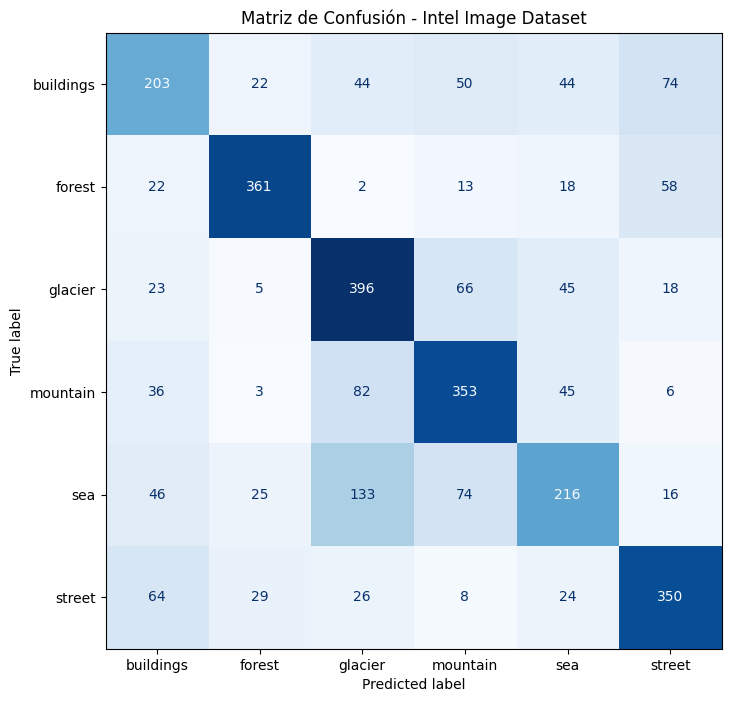

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=nombres_clases,
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title("Matriz de Confusión - Intel Image Dataset")
plt.show()